In [1]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as patches

import sys
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
sys.path.insert(1, str(E9path))
import E9_fn.thermodynamics as thmdy
from E9_fn import util
from E9_fn.tight_binding import E9tb
from projects.flat_band_cooling import helper_fns as hpfn

logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


In [2]:
lattice_str = "sawtooth"
lattice_len = 5
lattice_dim = (lattice_len, 1)
overwrite_param = {}
# overwrite_param = {"sublat_offsets": [0., 0., 0., 15.]}
tb_params = E9tb.get_model_params(lattice_str)
my_tb_model = E9tb.tbmodel_2D(lat_dim = lattice_dim, **tb_params)
H_bare = my_tb_model.H

H_total = H_bare

[]

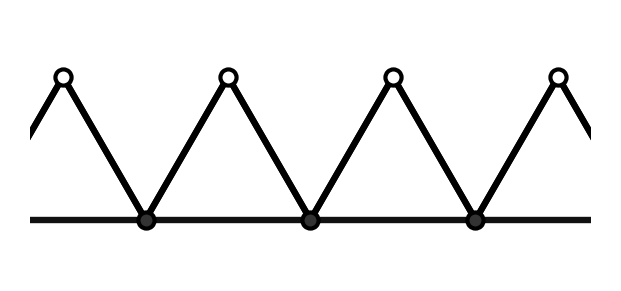

In [3]:
fig, ax = plt.subplots(1, 1, figsize = (3, 1), dpi = 300)

ax.axis("off")
my_tb_model.plot_H(ax = ax, H = H_total,
                sublat_colors = ["#333333", "#FFFFFF"],
                sublat_kwargs = {"edgecolors": "black",
                                    "linewidths": 1})

# ax.text(2.5, -0.1, r"$t$", ha = "center", va = "top", fontsize = 12)
# ax.text(3, 0.4, r"$t'$", ha = "center", va = "bottom", fontsize = 12)

ax.set_xlim(0.3, 3.7)
ax.set_ylim(-0.25, 1.15)
ax.set_xticks([])
ax.set_yticks([])

(-0.25, 1.15)

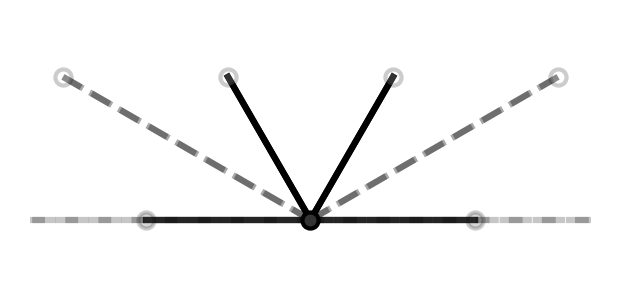

In [6]:
lattice_len = 5
lattice_dim = (lattice_len, 1)
center_uc = 2

# Load params, but remove the first 3 terms (the bare hoppings)
# so the model strictly contains H' and avoids the overwrite bug
tb_params_h_prime = E9tb.get_model_params("sawtooth_shifted")
tb_params_h_prime["hoppings"] = tb_params_h_prime["hoppings"][3:]

tb_h_prime = E9tb.tbmodel_2D(lat_dim = lattice_dim, **tb_params_h_prime)

# ---------------------------------------------------------
# Plot for Central A site
# ---------------------------------------------------------
idx_A = tb_h_prime.get_reduced_index(center_uc, 0, 0)

H_A = np.zeros_like(tb_h_prime.H)
H_A[idx_A, :] = tb_h_prime.H[idx_A, :]
H_A[:, idx_A] = tb_h_prime.H[:, idx_A]

# Manually zero out the extra B site on the far right edge
idx_B_far_right = tb_h_prime.get_reduced_index(4, 0, 1)
H_A[idx_A, idx_B_far_right] = 0
H_A[idx_B_far_right, idx_A] = 0

fig_A, ax_A = plt.subplots(1, 1, figsize = (3, 1), dpi = 300)
ax_A.axis("off")

tb_h_prime.plot_H(ax = ax_A, H = H_A,
                  sublat_colors = ["#333333", "#FFFFFF"],
                  sublat_kwargs = {"edgecolors": "black", "linewidths": 1})

ax_A.set_xlim(0.3, 3.7)
ax_A.set_ylim(-0.25, 1.15)

# # ---------------------------------------------------------
# # Plot for Central B site
# # ---------------------------------------------------------
# idx_B = tb_h_prime.get_reduced_index(center_uc, 0, 1)

# H_B = np.zeros_like(tb_h_prime.H)
# H_B[idx_B, :] = tb_h_prime.H[idx_B, :]
# H_B[:, idx_B] = tb_h_prime.H[:, idx_B]

# # Manually zero out the extra A site on the far left edge
# idx_A_far_left = tb_h_prime.get_reduced_index(0, 0, 0)
# H_B[idx_B, idx_A_far_left] = 0
# H_B[idx_A_far_left, idx_B] = 0

# fig_B, ax_B = plt.subplots(1, 1, figsize = (3, 1), dpi = 300)
# ax_B.axis("off")

# tb_h_prime.plot_H(ax = ax_B, H = H_B,
#                   sublat_colors = ["#333333", "#FFFFFF"],
#                   sublat_kwargs = {"edgecolors": "black", "linewidths": 1})

# ax_B.set_xlim(0.3, 3.7)
# ax_B.set_ylim(-0.25, 1.15)

[]

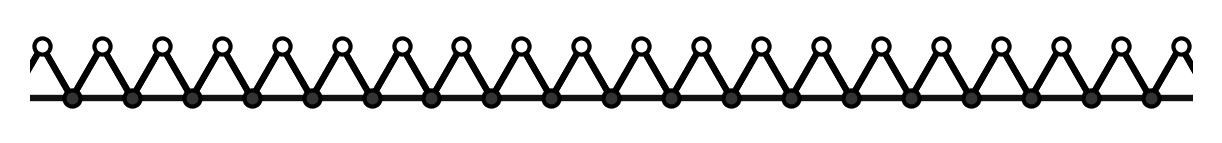

In [8]:
lattice_str = "sawtooth"
lattice_len = 22
lattice_dim = (lattice_len, 1)
overwrite_param = {}
# overwrite_param = {"sublat_offsets": [0., 0., 0., 15.]}
tb_params = E9tb.get_model_params(lattice_str)
my_tb_model = E9tb.tbmodel_2D(lat_dim = lattice_dim, **tb_params)
H_bare = my_tb_model.H

H_total = H_bare

fig, ax = plt.subplots(1, 1, figsize = (5, 0.5), dpi = 300)

ax.axis("off")
my_tb_model.plot_H(ax = ax, H = H_total,
                sublat_colors = ["#333333", "#FFFFFF"],
                sublat_kwargs = {"edgecolors": "black",
                                    "linewidths": 1})

# ax.text(2.5, -0.1, r"$t$", ha = "center", va = "top", fontsize = 12)
# ax.text(3, 0.4, r"$t'$", ha = "center", va = "bottom", fontsize = 12)

ax.set_xlim(0.3, 19.7)
ax.set_ylim(-0.25, 1.15)
ax.set_xticks([])
ax.set_yticks([])